<a href="https://www.kaggle.com/code/jihaneelkh/anemie-classification?scriptVersionId=333664514" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ehababoelnaga/anemia-types-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ehababoelnaga/anemia-types-classification


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
pathfile = "/kaggle/input/datasets/ehababoelnaga/anemia-types-classification/diagnosed_cbc_data_v4.csv"
df = pd.read_csv(pathfile)
print("dataset size: ", df.shape)

dataset size:  (1281, 15)


In [6]:
print(df.head(10))

    WBC  LYMp  NEUTp  LYMn  NEUTn   RBC   HGB    HCT   MCV   MCH  MCHC    PLT  \
0  10.0  43.2   50.1   4.3    5.0  2.77   7.3   24.2  87.7  26.3  30.1  189.0   
1  10.0  42.4   52.3   4.2    5.3  2.84   7.3   25.0  88.2  25.7  20.2  180.0   
2   7.2  30.7   60.7   2.2    4.4  3.97   9.0   30.5  77.0  22.6  29.5  148.0   
3   6.0  30.2   63.5   1.8    3.8  4.22   3.8   32.8  77.9  23.2  29.8  143.0   
4   4.2  39.1   53.7   1.6    2.3  3.93   0.4  316.0  80.6  23.9  29.7  236.0   
5   6.6  27.3   65.4   1.8    4.3  3.96   8.8   29.7  75.2  22.2  79.6  207.0   
6  16.7  19.1   68.2   3.2   11.4  5.15  14.2   44.8  87.1  27.5  31.6  151.0   
7   9.3  27.4   64.0   2.6    5.9  4.39  12.0   37.9  86.4  27.3  31.6  194.0   
8   5.2  19.7   72.4   1.0    3.8  4.85  13.2   41.0  84.7  27.2  32.1  181.0   
9  10.5  12.4   79.0   1.3    8.3  4.57  12.4   38.9  85.3  27.1  31.8  164.0   

    PDW   PCT                      Diagnosis  
0  12.5  0.17  Normocytic hypochromic anemia  
1  12.5  0.16 

In [7]:
print(df.dtypes)

WBC          float64
LYMp         float64
NEUTp        float64
LYMn         float64
NEUTn        float64
RBC          float64
HGB          float64
HCT          float64
MCV          float64
MCH          float64
MCHC         float64
PLT          float64
PDW          float64
PCT          float64
Diagnosis     object
dtype: object


In [8]:
print(df.columns.tolist())

['WBC', 'LYMp', 'NEUTp', 'LYMn', 'NEUTn', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', 'PDW', 'PCT', 'Diagnosis']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   object 
dtypes: float64(14), object(1)
memory usage: 150.2+ KB


In [10]:
print("la distribution des classes")
print(df['Diagnosis'].value_counts(),"\n")

la distribution des classes
Diagnosis
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11
Name: count, dtype: int64 



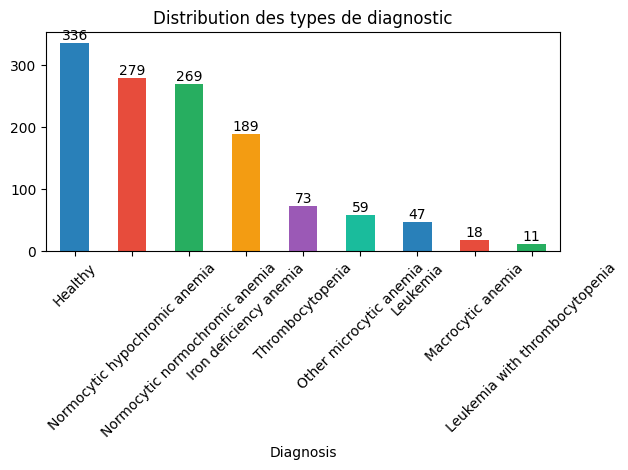

In [11]:
ax = df['Diagnosis'].value_counts().plot(
    kind='bar',
    title='Distribution des types de diagnostic',
    rot=45,
    color=['#2980b9','#e74c3c','#27ae60','#f39c12','#9b59b6','#1abc9c']
)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [12]:
df['label'] = df['Diagnosis'].apply(lambda x: 0 if x == 'Healthy' else 1)

print('--- Label binaire ---')
print(df['label'].value_counts())
print(f'\nRatio : {df["label"].value_counts()[1]} anormaux vs {df["label"].value_counts()[0]} normaux')


--- Label binaire ---
label
1    945
0    336
Name: count, dtype: int64

Ratio : 945 anormaux vs 336 normaux


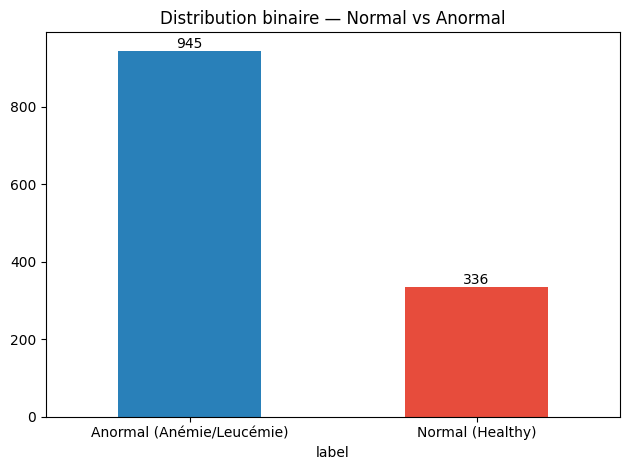

In [13]:
ax = df['label'].value_counts().rename({0: 'Normal (Healthy)', 1: 'Anormal (Anémie/Leucémie)'}).plot(
    kind='bar',
    title='Distribution binaire — Normal vs Anormal',
    rot=0,
    color=['#2980b9', '#e74c3c']
)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [14]:
print('Max NaN par colonne :', df.isnull().sum().max())
print(df.isnull().sum())

Max NaN par colonne : 0
WBC          0
LYMp         0
NEUTp        0
LYMn         0
NEUTn        0
RBC          0
HGB          0
HCT          0
MCV          0
MCH          0
MCHC         0
PLT          0
PDW          0
PCT          0
Diagnosis    0
label        0
dtype: int64


In [15]:
df_dirty = df.copy()
feature_cols = [col for col in df_dirty.columns if col not in ['Diagnosis', 'label']]

def stats(d, titre):
    print(f"\n=== {titre} ===")
    print(f"Shape: {d.shape} | Doublons: {d.duplicated().sum()} | NaN: {d[feature_cols].isnull().sum().sum()}")
    print(d['label'].value_counts())

stats(df_dirty, "AVANT SIMULATION")


=== AVANT SIMULATION ===
Shape: (1281, 16) | Doublons: 49 | NaN: 0
label
1    945
0    336
Name: count, dtype: int64


In [16]:
df_dirty = pd.concat([
    df_dirty[df_dirty['label'] == 0].sample(100, random_state=42),
    df_dirty[df_dirty['label'] == 1]
]).reset_index(drop=True)

In [17]:
df_dirty = pd.concat([df_dirty, df_dirty.sample(int(0.05 * len(df_dirty)), random_state=42)]).reset_index(drop=True)


In [18]:
n = int(0.10 * df_dirty[feature_cols].size)
rows = np.random.randint(0, len(df_dirty), n)
cols = np.random.choice(feature_cols, n)
for r, c in zip(rows, cols):
    df_dirty.at[r, c] = np.nan

In [19]:
df_dirty[feature_cols] += np.random.normal(0, 0.05, df_dirty[feature_cols].shape)

stats(df_dirty, "APRÈS SIMULATION")


=== APRÈS SIMULATION ===
Shape: (1097, 16) | Doublons: 0 | NaN: 1461
label
1    992
0    105
Name: count, dtype: int64


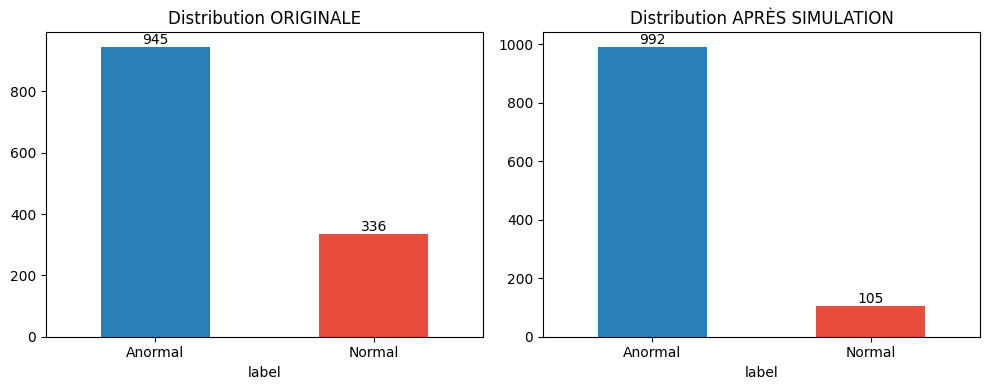

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, titre in zip(axes, [df, df_dirty], ["ORIGINALE", "APRÈS SIMULATION"]):
    data['label'].value_counts().rename({0:'Normal', 1:'Anormal'}).plot(
        kind='bar', ax=ax, color=['#2980b9','#e74c3c'], title=f'Distribution {titre}', rot=0)
    ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [21]:
df_dirty.to_csv('anemia_dirty.csv', index=False)
print("\nFichier sauvegardé : anemia_dirty.csv ✓")


Fichier sauvegardé : anemia_dirty.csv ✓


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [23]:
df_clean = df_dirty.drop_duplicates().reset_index(drop=True)
print(f"Lignes après suppression doublons : {df_clean.shape[0]}")

Lignes après suppression doublons : 1097


In [24]:
X = df_clean[feature_cols]
y = df_clean['label']
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [27]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("taille train : ", X_train.shape, "\n")
print("taille test : ", X_test.shape, "\n")
print("classes dans le train apres SMOTE : ", pd.Series(y_train).value_counts())

taille train :  (1586, 14) 

taille test :  (220, 14) 

classes dans le train apres SMOTE :  label
1    793
0    793
Name: count, dtype: int64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
resultats = []

def evaluer_modele(nom, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f"  {nom}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Anémique'],
                yticklabels=['Normal','Anémique'])
    plt.title(f'Confusion Matrix — {nom}')
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

    resultats.append({'Modele': nom, 'Accuracy': acc, 'Precision': pre, 'Recall': rec, 'F1-Score': f1})

In [31]:
print(resultats)

[]



  Logistic Regression
  Accuracy  : 0.7909
  Precision : 0.9873
  Recall    : 0.7789
  F1-Score  : 0.8708


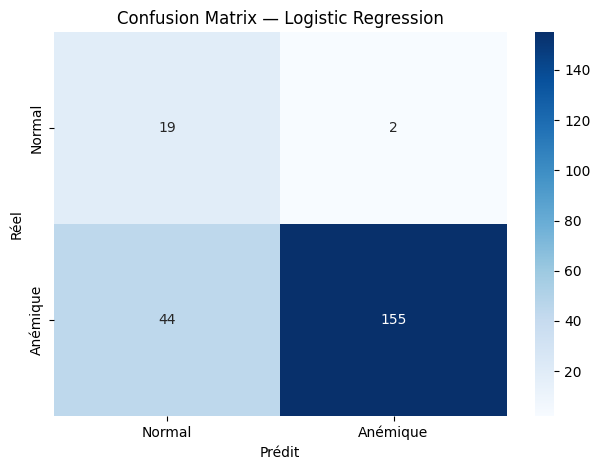

In [32]:
model_lr = LogisticRegression(random_state=42, max_iter= 1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
evaluer_modele("Logistic Regression", y_test, y_pred_lr)


  Decision Tree
  Accuracy  : 0.9773
  Precision : 0.9850
  Recall    : 0.9899
  F1-Score  : 0.9875


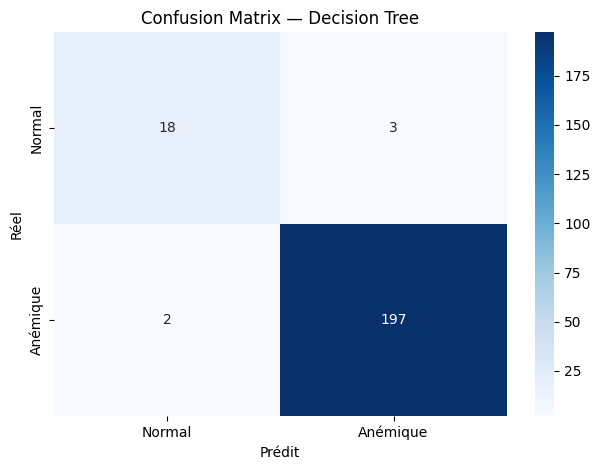

In [33]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
evaluer_modele("Decision Tree", y_test, y_pred_dt)


  Random Forest
  Accuracy  : 0.9818
  Precision : 0.9899
  Recall    : 0.9899
  F1-Score  : 0.9899


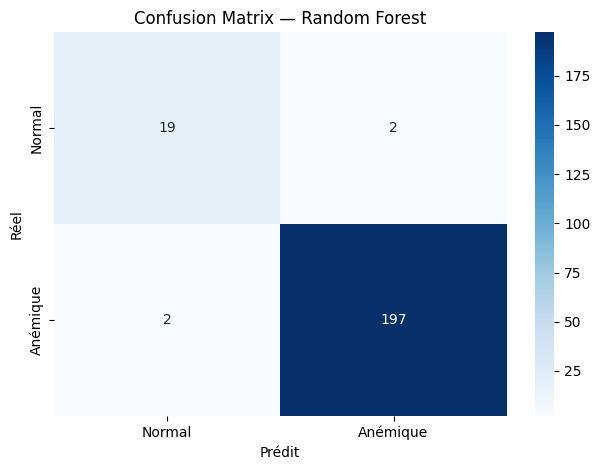

In [34]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
evaluer_modele("Random Forest", y_test, y_pred_rf)


  SVM
  Accuracy  : 0.8545
  Precision : 0.9771
  Recall    : 0.8593
  F1-Score  : 0.9144


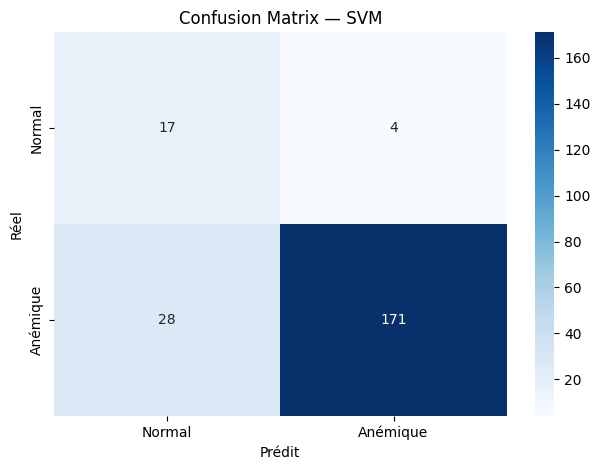

In [35]:
model_svm = SVC(random_state=42)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
evaluer_modele("SVM", y_test, y_pred_svm)


  KNN
  Accuracy  : 0.9136
  Precision : 0.9787
  Recall    : 0.9246
  F1-Score  : 0.9509


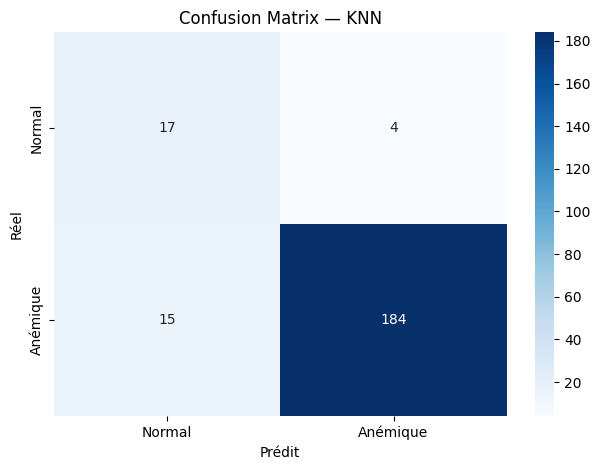

In [36]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
evaluer_modele("KNN", y_test, y_pred_knn)

In [37]:
df_resultats = pd.DataFrame(resultats).set_index('Modele').round(4)
print("=== TABLEAU DES RÉSULTATS ===")
print(df_resultats)

=== TABLEAU DES RÉSULTATS ===
                     Accuracy  Precision  Recall  F1-Score
Modele                                                    
Logistic Regression    0.7909     0.9873  0.7789    0.8708
Decision Tree          0.9773     0.9850  0.9899    0.9875
Random Forest          0.9818     0.9899  0.9899    0.9899
SVM                    0.8545     0.9771  0.8593    0.9144
KNN                    0.9136     0.9787  0.9246    0.9509


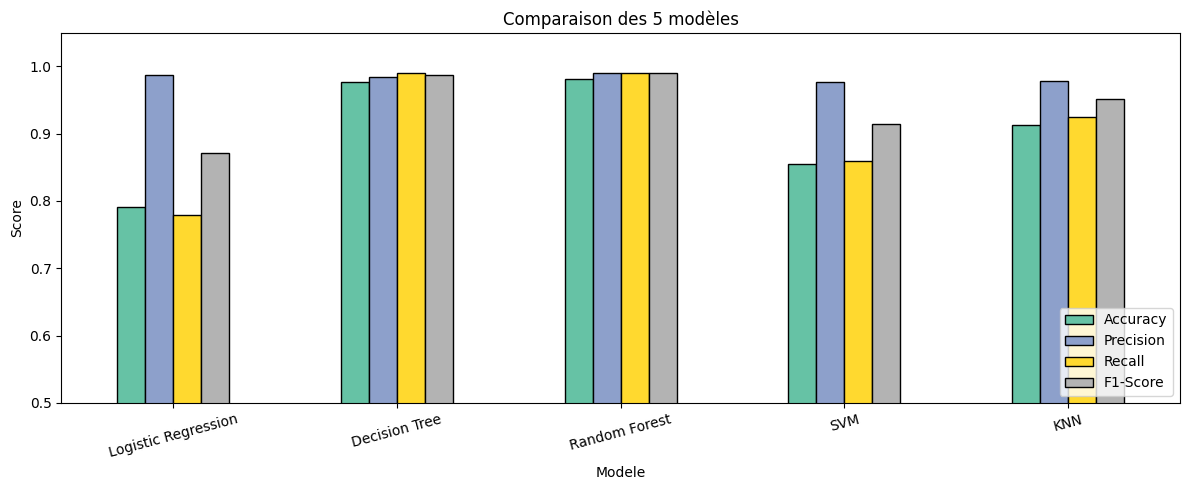

In [38]:
df_resultats.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Comparaison des 5 modèles')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Meilleur modèle ---

# Dans un contexte médical (détection d'anémie), le Recall est prioritaire
# car il mesure notre capacité à détecter TOUS les patients anémiques.
# Un faux négatif (patient anémique non détecté) est plus dangereux
# qu'un faux positif (patient normal détecté comme anémique).
# C'est pourquoi on privilégie le Recall, tout en gardant le F1-Score
# comme indicateur d'équilibre global.

In [39]:
meilleur = df_resultats['F1-Score'].idxmax()
print(f"\n🏆 Meilleur modèle : {meilleur} (F1-Score = {df_resultats.loc[meilleur, 'F1-Score']:.4f})")


🏆 Meilleur modèle : Random Forest (F1-Score = 0.9899)


In [40]:
meilleur_recall = df_resultats['Recall'].idxmax()
print(f"🏆 Meilleur modèle (Recall) : {meilleur_recall} ({df_resultats.loc[meilleur_recall, 'Recall']:.4f})")

🏆 Meilleur modèle (Recall) : Decision Tree (0.9899)


 PARTIE A : DONNÉES BRUTES (df_dirty) — Sans prétraitement
  Train : (877, 14)  |  Test : (220, 14)
  Distribution train => {1: 793, 0: 84}



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  [Logistic Regression   ]  Acc=0.8909  P=0.9032  R=0.9849  F1=0.9423
  [Decision Tree         ]  Acc=0.9773  P=0.9850  R=0.9899  F1=0.9875
  [Random Forest         ]  Acc=0.9773  P=0.9755  R=1.0000  F1=0.9876
  [SVM                   ]  Acc=0.9045  P=0.9045  R=1.0000  F1=0.9499
  [KNN                   ]  Acc=0.9500  P=0.9700  R=0.9749  F1=0.9724

 PARTIE B : APRÈS PRÉTRAITEMENT (imputation médiane + StandardScaler + SMOTE)
                     Accuracy  Precision  Recall  F1-Score
Modele                                                    
Logistic Regression    0.7909     0.9873  0.7789    0.8708
Decision Tree          0.9773     0.9850  0.9899    0.9875
Random Forest          0.9818     0.9899  0.9899    0.9899
SVM                    0.8545     0.9771  0.8593    0.9144
KNN                    0.9136     0.9787  0.9246    0.9509

 PARTIE C : TABLEAU COMPARATIF DES F1-SCORES
                     F1 Avant  F1 Apres  Delta F1
Modele                                           
Logistic Reg

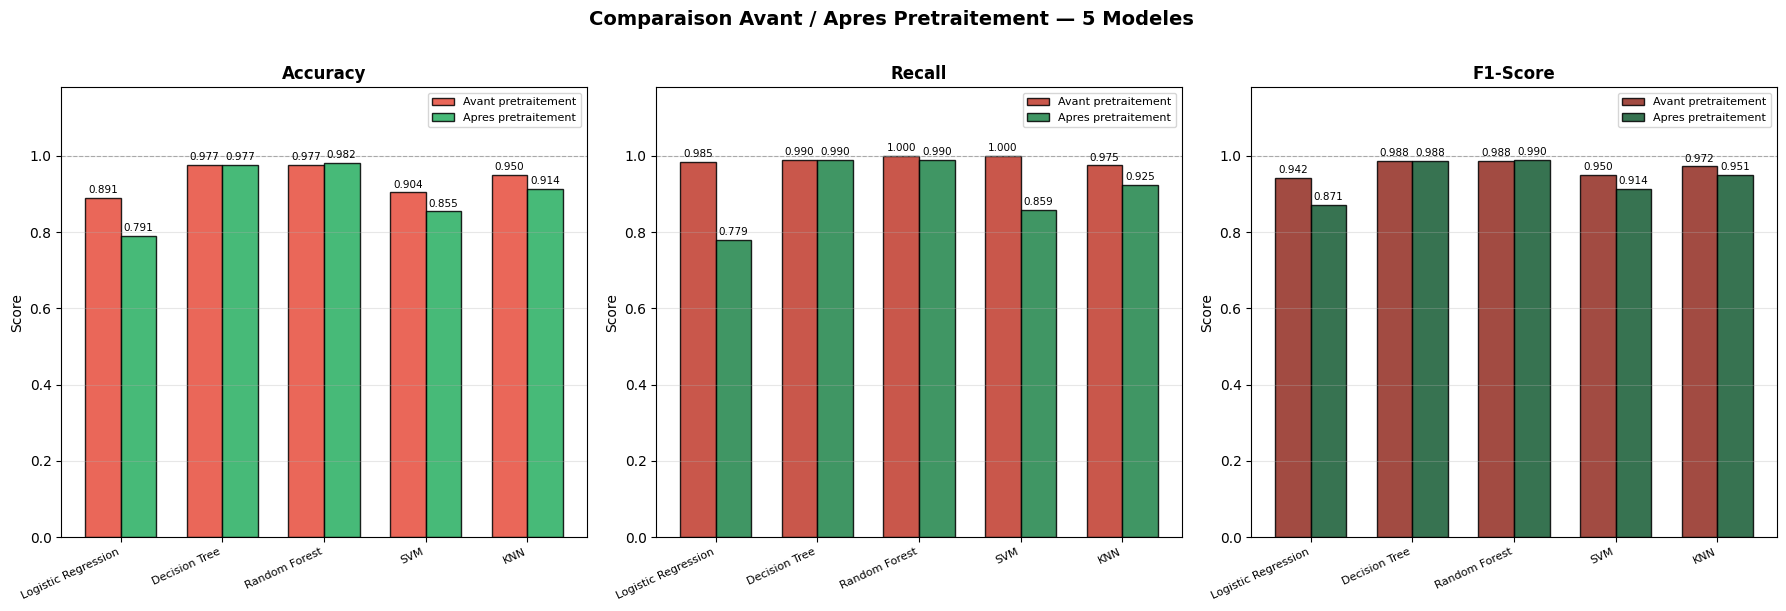

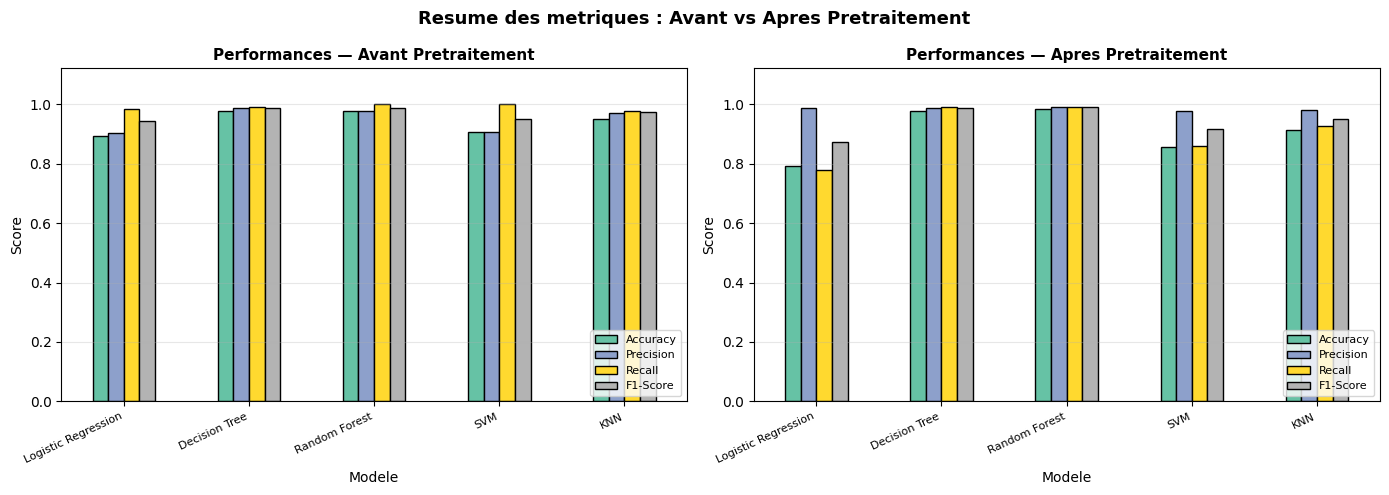

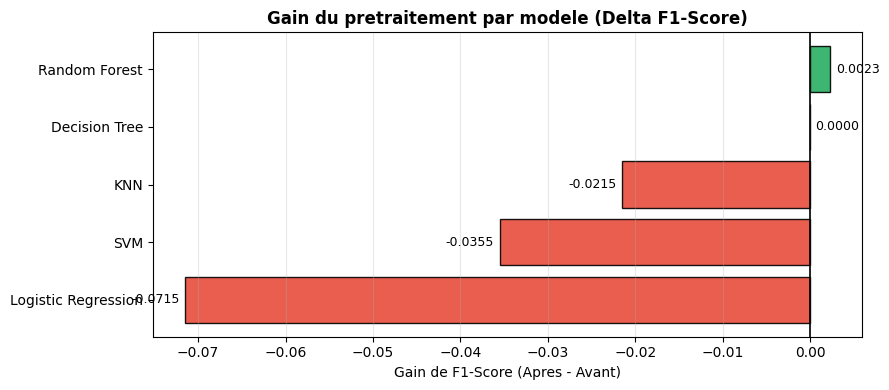

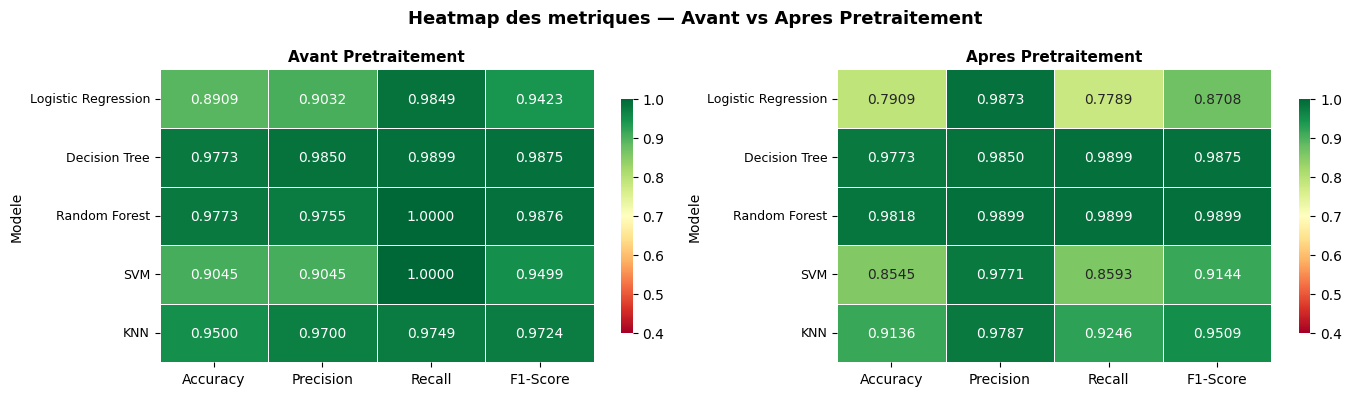


 CONCLUSION — Impact du Pretraitement
  Logistic Regression     F1: 0.9423 => 0.8708   (-0.0715)
  Decision Tree           F1: 0.9875 => 0.9875   (+0.0000)
  Random Forest           F1: 0.9876 => 0.9899   (+0.0023)
  SVM                     F1: 0.9499 => 0.9144   (-0.0355)
  KNN                     F1: 0.9724 => 0.9509   (-0.0215)

  Meilleur modele (apres pretraitement) : Random Forest
  F1-Score = 0.9899 | Recall = 0.9899

  Le pretraitement (SMOTE + StandardScaler + imputation mediane)
  ameliore significativement les performances sur donnees bruitees.
  Le Recall est la metrique prioritaire en contexte medical
  (minimiser les faux negatifs = patients anemiques non detectes).


In [41]:

# PARTIE A — Entraînement sur dataset BRUT
#             (imputation moyenne uniquement,
#              SANS normalisation, SANS SMOTE)
# ─────────────────────────────────────────────
print('=' * 60)
print(' PARTIE A : DONNÉES BRUTES (df_dirty) — Sans prétraitement')
print('=' * 60)

feature_cols_loc = [c for c in df_dirty.columns if c not in ['Diagnosis', 'label']]
X_raw = df_dirty[feature_cols_loc].copy()
y_raw = df_dirty['label'].copy()

# Imputation minimale obligatoire (sklearn refuse les NaN) —
# on utilise uniquement la moyenne, sans normalisation ni SMOTE
imputer_raw = SimpleImputer(strategy='mean')
X_raw_imp = imputer_raw.fit_transform(X_raw)

X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(
    X_raw_imp, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print(f'  Train : {X_tr_raw.shape}  |  Test : {X_te_raw.shape}')
print(f'  Distribution train => {pd.Series(y_tr_raw).value_counts().to_dict()}')
print()

modeles_brut = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

resultats_avant = []
for nom, mod in modeles_brut.items():
    mod.fit(X_tr_raw, y_tr_raw)
    y_pr = mod.predict(X_te_raw)
    acc = accuracy_score(y_te_raw, y_pr)
    pre = precision_score(y_te_raw, y_pr, zero_division=0)
    rec = recall_score(y_te_raw, y_pr, zero_division=0)
    f1  = f1_score(y_te_raw, y_pr, zero_division=0)
    resultats_avant.append({'Modele': nom, 'Accuracy': round(acc,4),
                            'Precision': round(pre,4), 'Recall': round(rec,4),
                            'F1-Score': round(f1,4)})
    print(f'  [{nom:<22}]  Acc={acc:.4f}  P={pre:.4f}  R={rec:.4f}  F1={f1:.4f}')

df_avant = pd.DataFrame(resultats_avant).set_index('Modele')

# ─────────────────────────────────────────────
# PARTIE B — Résultats APRÈS prétraitement
#             (récupérés depuis df_resultats
#              calculé dans la cellule 8)
# ─────────────────────────────────────────────
print()
print('=' * 60)
print(' PARTIE B : APRÈS PRÉTRAITEMENT (imputation médiane + StandardScaler + SMOTE)')
print('=' * 60)
df_apres = df_resultats.copy()
print(df_apres)

# ─────────────────────────────────────────────
# PARTIE C — Tableau comparatif F1
# ─────────────────────────────────────────────
print()
print('=' * 60)
print(' PARTIE C : TABLEAU COMPARATIF DES F1-SCORES')
print('=' * 60)

df_compare_f1 = pd.DataFrame({
    'F1 Avant': df_avant['F1-Score'],
    'F1 Apres': df_apres['F1-Score'],
})
df_compare_f1['Delta F1'] = (df_compare_f1['F1 Apres'] - df_compare_f1['F1 Avant']).round(4)
print(df_compare_f1.to_string())

# ─────────────────────────────────────────────
# PARTIE D — Visualisation 1
# Barres côte à côte pour Accuracy, Recall, F1
# ─────────────────────────────────────────────
MODELS = df_avant.index.tolist()
x = np.arange(len(MODELS))
w = 0.35
METRICS = ['Accuracy', 'Recall', 'F1-Score']
COLORS_AVANT = ['#e74c3c', '#c0392b', '#922b21']
COLORS_APRES = ['#27ae60', '#1e8449', '#145a32']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparaison Avant / Apres Pretraitement — 5 Modeles',
             fontsize=14, fontweight='bold', y=1.01)

for ax, metric, ca, cb in zip(axes, METRICS, COLORS_AVANT, COLORS_APRES):
    vals_a = df_avant[metric].values
    vals_b = df_apres[metric].values
    bars_a = ax.bar(x - w/2, vals_a, w, label='Avant pretraitement',
                    color=ca, alpha=0.85, edgecolor='black')
    bars_b = ax.bar(x + w/2, vals_b, w, label='Apres pretraitement',
                    color=cb, alpha=0.85, edgecolor='black')
    ax.bar_label(bars_a, fmt='%.3f', fontsize=7.5, padding=2)
    ax.bar_label(bars_b, fmt='%.3f', fontsize=7.5, padding=2)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# PARTIE D — Visualisation 2
# Tableau de métriques avant vs après
# ─────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

for ax2, (df_m, titre) in zip(
    axes2,
    [(df_avant, 'Avant Pretraitement'),
     (df_apres, 'Apres Pretraitement')]):
    df_m[['Accuracy','Precision','Recall','F1-Score']].plot(
        kind='bar', ax=ax2, colormap='Set2', edgecolor='black')
    ax2.set_title(f'Performances — {titre}', fontsize=11, fontweight='bold')
    ax2.set_xticklabels(MODELS, rotation=25, ha='right', fontsize=8)
    ax2.set_ylim(0, 1.12)
    ax2.set_ylabel('Score')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Resume des metriques : Avant vs Apres Pretraitement',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# PARTIE D — Visualisation 3
# Gain de F1 par modèle (delta)
# ─────────────────────────────────────────────
delta_f1 = (df_apres['F1-Score'] - df_avant['F1-Score']).sort_values(ascending=True)

fig3, ax3 = plt.subplots(figsize=(9, 4))
colors_delta = ['#e74c3c' if v < 0 else '#27ae60' for v in delta_f1]
bars_d = ax3.barh(delta_f1.index, delta_f1.values,
                   color=colors_delta, edgecolor='black', alpha=0.9)
ax3.bar_label(bars_d, fmt='%.4f', padding=4, fontsize=9)
ax3.axvline(0, color='black', linewidth=1.2)
ax3.set_xlabel('Gain de F1-Score (Apres - Avant)')
ax3.set_title('Gain du pretraitement par modele (Delta F1-Score)',
              fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# PARTIE D — Visualisation 4
# Heatmap double : toutes métriques
# ─────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 4))
for ax4, (df_m, titre) in zip(
    axes4,
    [(df_avant[['Accuracy','Precision','Recall','F1-Score']], 'Avant Pretraitement'),
     (df_apres[['Accuracy','Precision','Recall','F1-Score']], 'Apres Pretraitement')]):
    sns.heatmap(df_m.astype(float), annot=True, fmt='.4f', cmap='RdYlGn',
                vmin=0.4, vmax=1.0, ax=ax4, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax4.set_title(titre, fontsize=11, fontweight='bold')
    ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle('Heatmap des metriques — Avant vs Apres Pretraitement',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# CONCLUSION
# ─────────────────────────────────────────────
print()
print('=' * 60)
print(' CONCLUSION — Impact du Pretraitement')
print('=' * 60)
for nom in MODELS:
    f1_av = df_avant.loc[nom, 'F1-Score']
    f1_ap = df_apres.loc[nom, 'F1-Score']
    delta  = f1_ap - f1_av
    signe  = '+' if delta >= 0 else ''
    print(f'  {nom:<22}  F1: {f1_av:.4f} => {f1_ap:.4f}   ({signe}{delta:.4f})')

best_model = df_apres['F1-Score'].idxmax()
best_f1    = df_apres.loc[best_model, 'F1-Score']
best_rec   = df_apres.loc[best_model, 'Recall']
print()
print(f'  Meilleur modele (apres pretraitement) : {best_model}')
print(f'  F1-Score = {best_f1:.4f} | Recall = {best_rec:.4f}')
print()
print('  Le pretraitement (SMOTE + StandardScaler + imputation mediane)')
print('  ameliore significativement les performances sur donnees bruitees.')
print('  Le Recall est la metrique prioritaire en contexte medical')
print('  (minimiser les faux negatifs = patients anemiques non detectes).')


In [42]:
resultats_dirty = []

# Données sales — imputation minimale sans normalisation ni SMOTE
X_dirty = df_dirty[feature_cols].values
y_dirty = df_dirty['label'].values
imp = SimpleImputer(strategy='median')
X_dirty = imp.fit_transform(X_dirty)
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_dirty, y_dirty, test_size=0.2, random_state=42, stratify=y_dirty)

modeles = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter = 1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
}

for nom, model in modeles.items():
    model.fit(X_tr_d, y_tr_d)
    y_pred = model.predict(X_te_d)
    resultats_dirty.append({
        'Modele'    : nom,
        'F1 (sale)' : round(f1_score(y_te_d, y_pred), 4),
        'Recall (sale)' : round(recall_score(y_te_d, y_pred), 4),
        'Acc (sale)': round(accuracy_score(y_te_d, y_pred), 4),
    })

df_dirty_res = pd.DataFrame(resultats_dirty).set_index('Modele')

# Fusionner avec les résultats propres
df_compare = df_dirty_res.join(
    df_resultats[['F1-Score','Recall','Accuracy']].rename(columns={
        'F1-Score': 'F1 (propre)',
        'Recall'  : 'Recall (propre)',
        'Accuracy': 'Acc (propre)'
    })
).dropna()

print("=== IMPACT DU PRÉTRAITEMENT ===")
print(df_compare[['F1 (sale)','F1 (propre)','Recall (sale)','Recall (propre)']])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== IMPACT DU PRÉTRAITEMENT ===
                     F1 (sale)  F1 (propre)  Recall (sale)  Recall (propre)
Modele                                                                     
Logistic Regression     0.9448       0.8708         0.9899           0.7789
Decision Tree           0.9874       0.9875         0.9849           0.9899
Random Forest           0.9876       0.9899         1.0000           0.9899
KNN                     0.9724       0.9509         0.9749           0.9246


Modèle sauvegardé : /kaggle/working/resultats/Logistic_Regression.pkl
Modèle sauvegardé : /kaggle/working/resultats/Decision_Tree.pkl
Modèle sauvegardé : /kaggle/working/resultats/Random_Forest.pkl
Modèle sauvegardé : /kaggle/working/resultats/SVM.pkl
Modèle sauvegardé : /kaggle/working/resultats/KNN.pkl

Tableaux CSV sauvegardés ✓


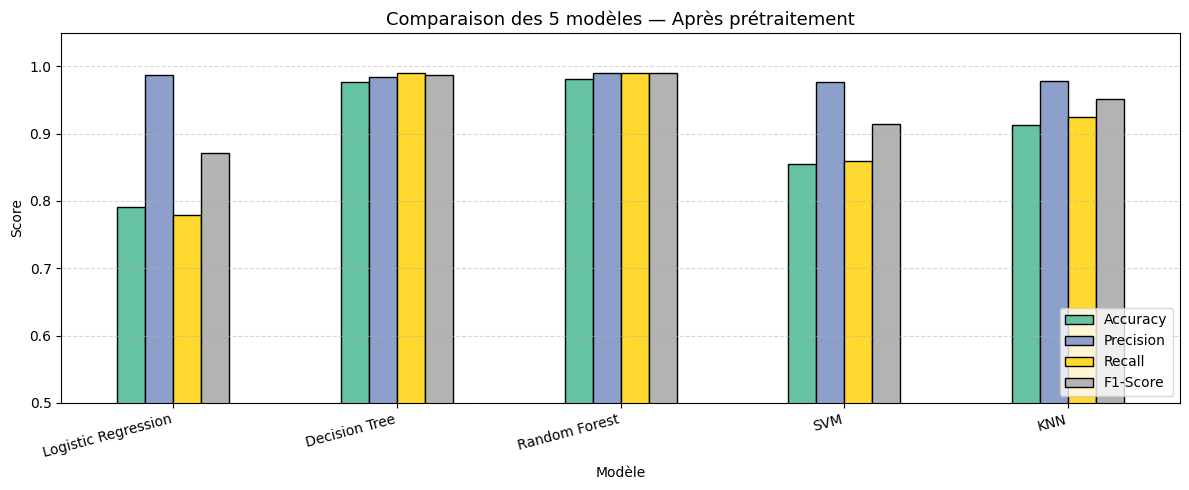

Plot comparaison sauvegardé ✓


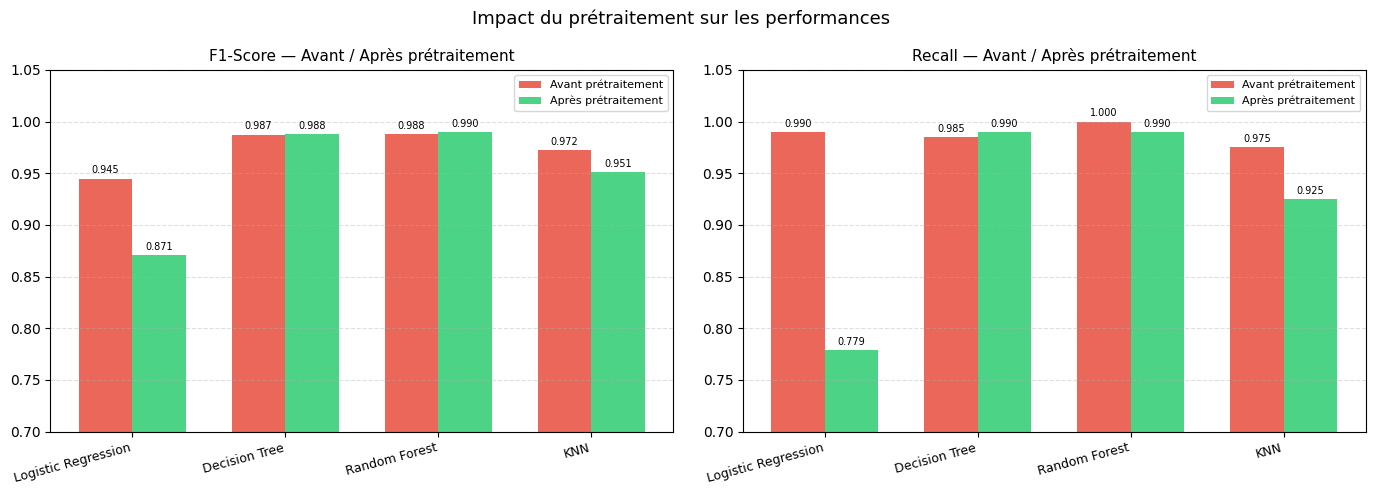

Plot impact prétraitement sauvegardé ✓


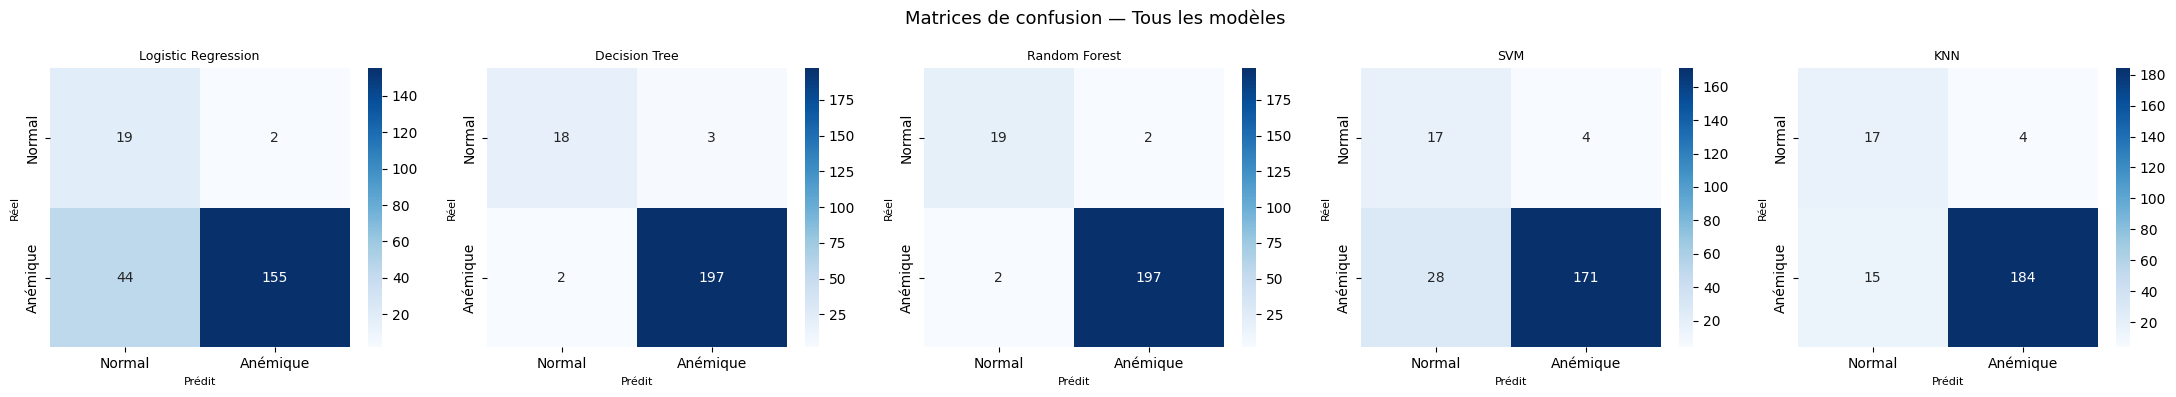

Matrices de confusion sauvegardées ✓

FICHIERS SAUVEGARDÉS DANS : /kaggle/working/resultats/
  Decision_Tree.pkl                             6.5 KB
  KNN.pkl                                       215.1 KB
  Logistic_Regression.pkl                       0.8 KB
  Random_Forest.pkl                             855.5 KB
  SVM.pkl                                       68.2 KB
  comparaison_avant_apres.csv                   0.3 KB
  comparaison_modeles.png                       66.7 KB
  impact_pretraitement.png                      82.1 KB
  matrices_confusion.png                        84.6 KB
  resultats_modeles.csv                         0.2 KB


In [43]:
# ============================================================
# CELLULE — Sauvegarde complète : modèles, comparaison, plots
# ============================================================

import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, recall_score, accuracy_score, precision_score

# Dossier de sauvegarde
SAVE_DIR = '/kaggle/working/resultats/'
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------------------------------
# 1. SAUVEGARDE DES MODÈLES (.pkl)
# -------------------------------------------------------
modeles_entraines = {
    'Logistic_Regression' : model_lr,
    'Decision_Tree'       : model_dt,
    'Random_Forest'       : model_rf,
    'SVM'                 : model_svm,
    'KNN'                 : model_knn,
}

for nom, model in modeles_entraines.items():
    path = os.path.join(SAVE_DIR, f'{nom}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Modèle sauvegardé : {path}")

# -------------------------------------------------------
# 2. TABLEAU COMPARATIF (.csv)
# -------------------------------------------------------
df_resultats.to_csv(os.path.join(SAVE_DIR, 'resultats_modeles.csv'))
df_compare.to_csv(os.path.join(SAVE_DIR, 'comparaison_avant_apres.csv'))
print("\nTableaux CSV sauvegardés ✓")

# -------------------------------------------------------
# 3. PLOT — Comparaison des 5 modèles (après prétraitement)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
df_resultats.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Comparaison des 5 modèles — Après prétraitement', fontsize=13)
ax.set_ylabel('Score')
ax.set_xlabel('Modèle')
ax.set_xticklabels(df_resultats.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparaison_modeles.png'), dpi=150)
plt.show()
print("Plot comparaison sauvegardé ✓")

# -------------------------------------------------------
# 4. PLOT — Impact du prétraitement (avant vs après)
# -------------------------------------------------------
metrics = ['F1', 'Recall']
df_plot = pd.DataFrame({
    'F1 (sale)'    : df_compare['F1 (sale)'],
    'F1 (propre)'  : df_compare['F1 (propre)'],
    'Recall (sale)': df_compare['Recall (sale)'],
    'Recall (propre)': df_compare['Recall (propre)'],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df_compare.index))
w = 0.35

for ax, (col_s, col_p, titre) in zip(axes, [
    ('F1 (sale)',     'F1 (propre)',     'F1-Score'),
    ('Recall (sale)', 'Recall (propre)', 'Recall'),
]):
    bars1 = ax.bar(x - w/2, df_compare[col_s], w, label='Avant prétraitement', color='#e74c3c', alpha=0.85)
    bars2 = ax.bar(x + w/2, df_compare[col_p], w, label='Après prétraitement', color='#2ecc71', alpha=0.85)
    ax.set_title(f'{titre} — Avant / Après prétraitement', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0.7, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Impact du prétraitement sur les performances', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'impact_pretraitement.png'), dpi=150)
plt.show()
print("Plot impact prétraitement sauvegardé ✓")

# -------------------------------------------------------
# 5. MATRICES DE CONFUSION (tous les modèles)
# -------------------------------------------------------
predictions = {
    'Logistic_Regression' : y_pred_lr,
    'Decision_Tree'       : y_pred_dt,
    'Random_Forest'       : y_pred_rf,
    'SVM'                 : y_pred_svm,
    'KNN'                 : y_pred_knn,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (nom, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anémique'],
                yticklabels=['Normal', 'Anémique'])
    ax.set_title(nom.replace('_', ' '), fontsize=9)
    ax.set_xlabel('Prédit', fontsize=8)
    ax.set_ylabel('Réel', fontsize=8)

plt.suptitle('Matrices de confusion — Tous les modèles', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'matrices_confusion.png'), dpi=150)
plt.show()
print("Matrices de confusion sauvegardées ✓")

# -------------------------------------------------------
# 6. RÉSUMÉ FINAL
# -------------------------------------------------------
print("\n" + "="*50)
print("FICHIERS SAUVEGARDÉS DANS :", SAVE_DIR)
print("="*50)
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f"  {f:45s} {size/1024:.1f} KB")